In [1]:
from gymnasium.wrappers import TimeLimit

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import (
    DummyVecEnv, 
    VecNormalize,
    VecFrameStack, 
    VecTransposeImage
)

from src.mygym.lunar_lander import MyLunarLander
from src.wrapper.visual_wrapper import VisualWrapper
from src.wrapper.pendulum_wrapper import ResizeObservation


In [2]:
def make_env(seed, **kwargs):
    def _init():
        env = MyLunarLander(
                        render_mode="rgb_array", 
                        continuous=True
                        )
        # env = LoggingWrapper(env)  # For debugging: log each step. Comment out by default
        env = VisualWrapper(env)
        env = TimeLimit(env, max_episode_steps=kwargs.get("episode_timesteps"))
        env = ResizeObservation(env, 
                                (kwargs.get("image_height"), 
                                 kwargs.get("image_width")))
        env.reset(seed=seed)
        return env
    return _init

In [18]:
config = {
    "episode_timesteps": 1024,
    "image_height": 256,
    "image_width": 256,
    "n_stacked_frame": 4
}

env = DummyVecEnv([make_env(0, **config)])
# env = VecFrameStack(env, n_stack=config.get("n_stacked_frame"))
env = VecTransposeImage(env)
env = VecNormalize(env, norm_obs=False, norm_reward=True, clip_obs=10.0)

In [19]:
obs = env.reset()
obs.shape

(1, 3, 256, 256)

In [5]:
import numpy as np

np.squeeze(obs).shape

(12, 256, 256)

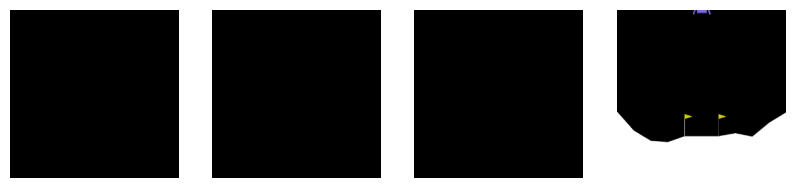

In [6]:
import matplotlib.pyplot as plt

def plot_obs(obs, title="", n_frame=4):
    fig, axes = plt.subplots(1, n_frame, figsize=(10, 5))

    tmp_obs = np.squeeze(obs)

    axes[0].set_title(title)
    for id, ax in enumerate(axes):
        tmp_img = tmp_obs[id*3: id*3+3, :, :].transpose(1, 2, 0).astype(int)
        ax.imshow(tmp_img)
        ax.axis("off")
    
plot_obs(obs, n_frame=4)

In [7]:
import pandas as pd

log_fn = "../../run/ppo_vislunarlander_default/logs/ppo_vislunarlander_eval_default_seed_42.pkl"

with open(log_fn, "rb") as f:
    df = pd.read_pickle(f)
df

,state,action,reward,accumulated_reward
0,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,"[[0.49566668, 0.4423506]]",[-1.5396507],[-1.5396507]
1,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,"[[0.19074675, -0.12688336]]",[-2.2712507],[-3.8109014]
2,[[[[ 0 0 0 0 0 0 0 0 0 0 ...,"[[-0.3764449, -0.83628076]]",[1.8227168],[-1.9881846]
3,[[[[ 0 0 0 0 0 0 0 0 0 0 ...,"[[-0.13465062, 0.07034704]]",[1.3930624],[-0.5951222]
4,[[[[ 0 0 0 0 0 0 0 0 0 0 ...,"[[-0.15747835, -0.51218104]]",[1.834654],[1.2395318]
...,...,...,...,...
118,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,"[[0.60241044, 1.0]]",[-4.2640862],[-157.39133]
119,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,"[[-0.05002436, -0.06215533]]",[30.028608],[-127.36272]
120,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,"[[-0.9597223, -0.3361919]]",[-22.862293],[-150.225]
121,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,"[[-0.45308506, -0.21106082]]",[-33.869602],[-184.0946]


/tmp/ipykernel_15047/230449641.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, n_frame, figsize=(10, 5))


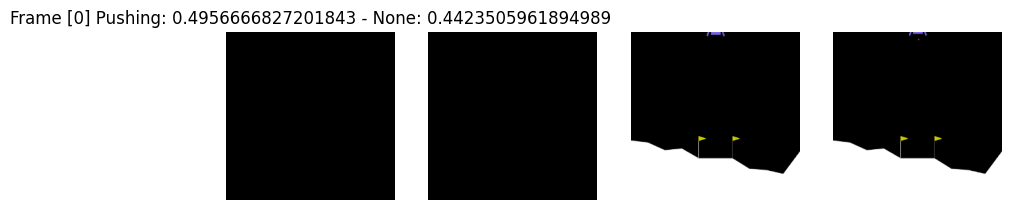

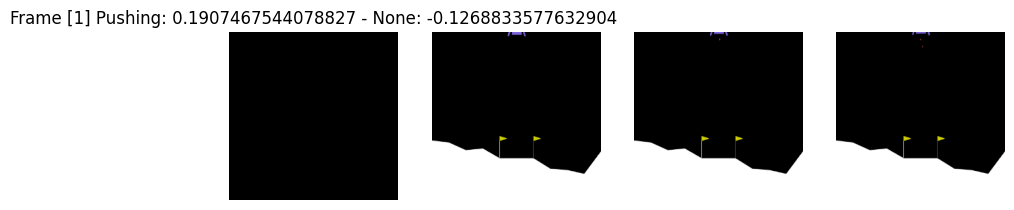

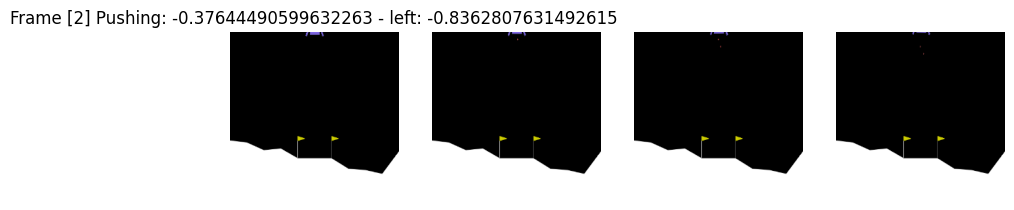

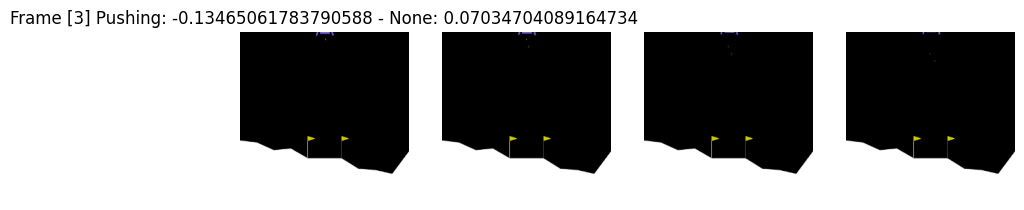

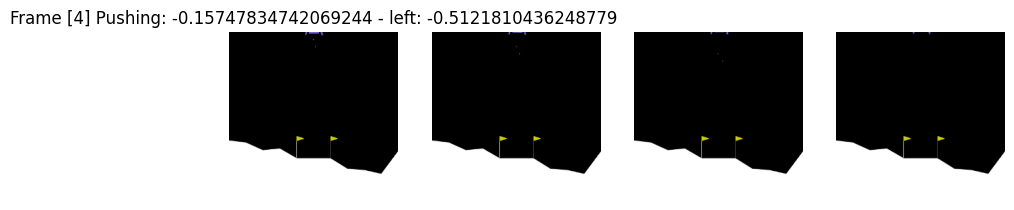

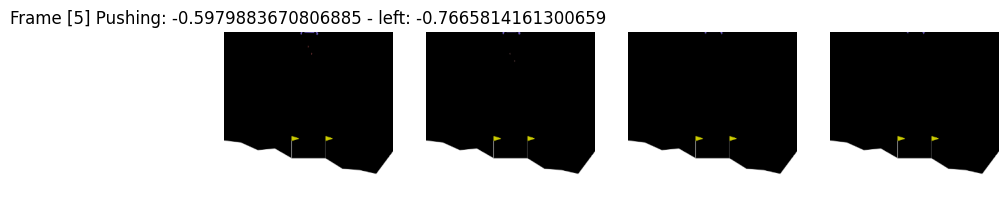

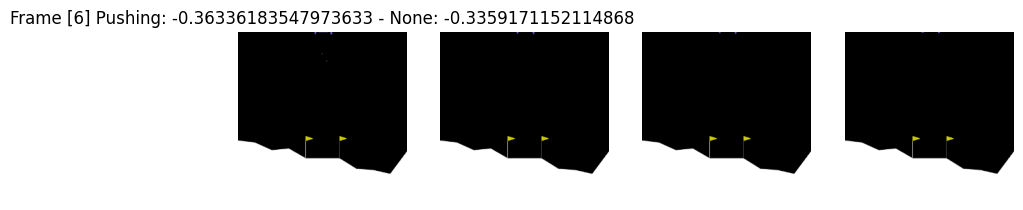

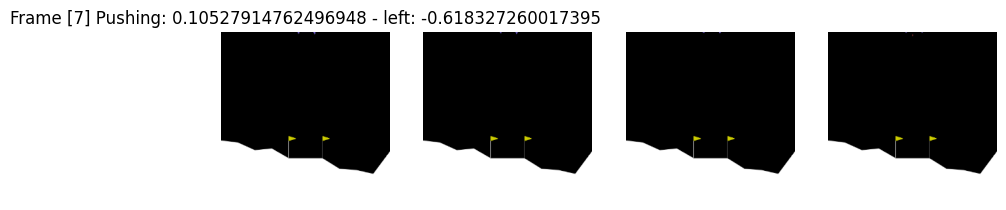

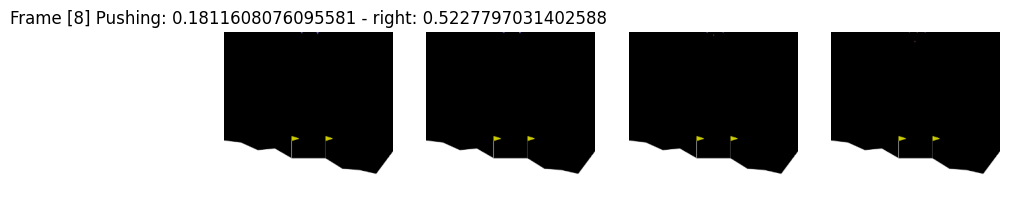

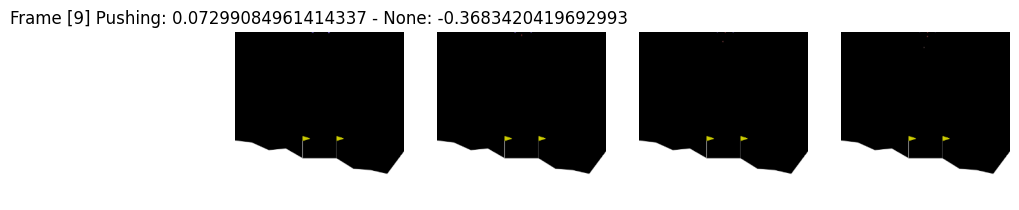

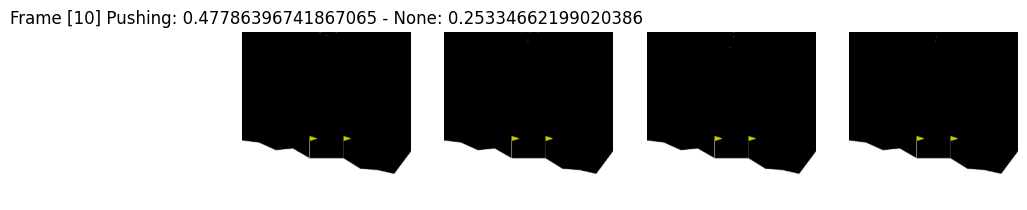

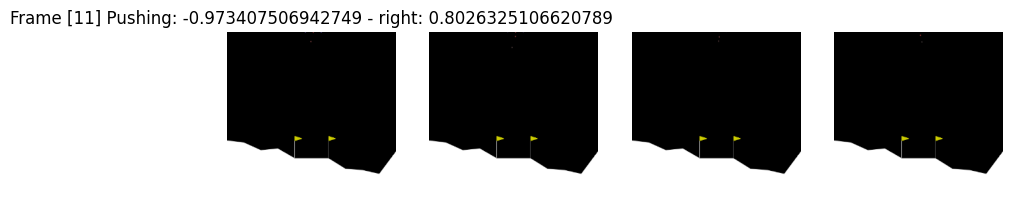

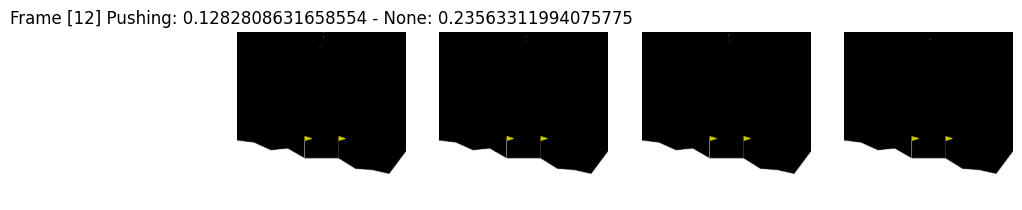

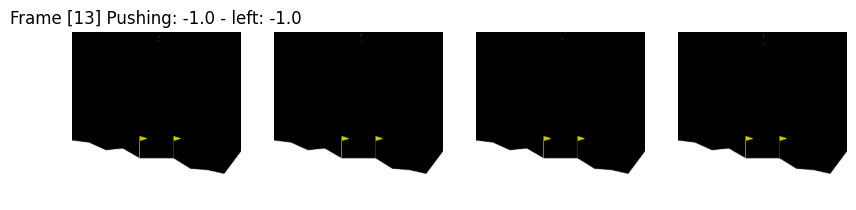

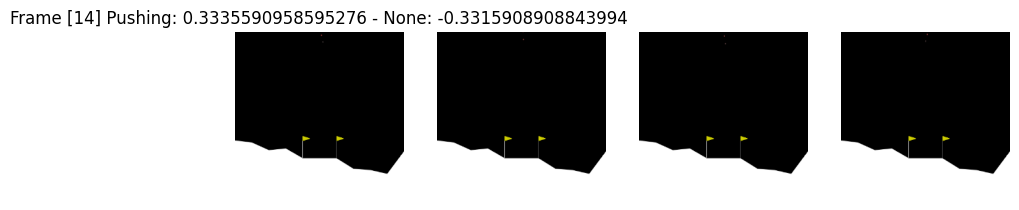

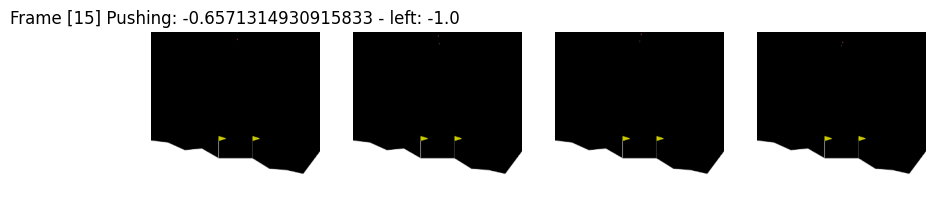

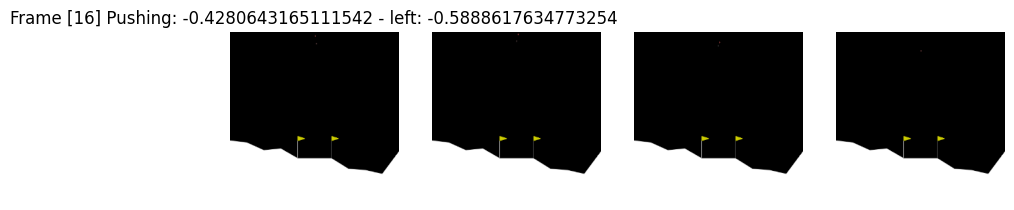

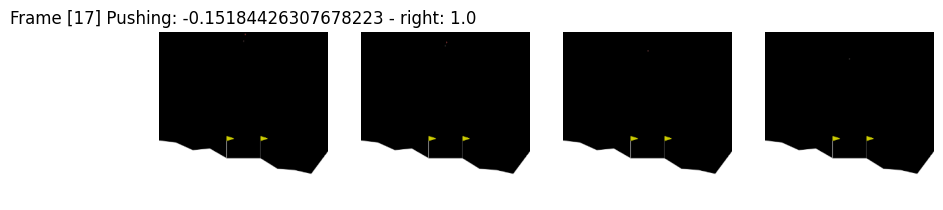

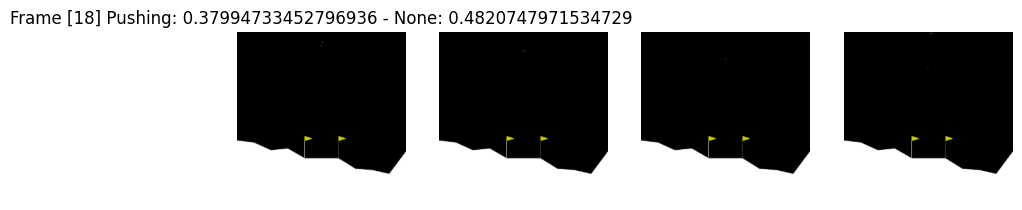

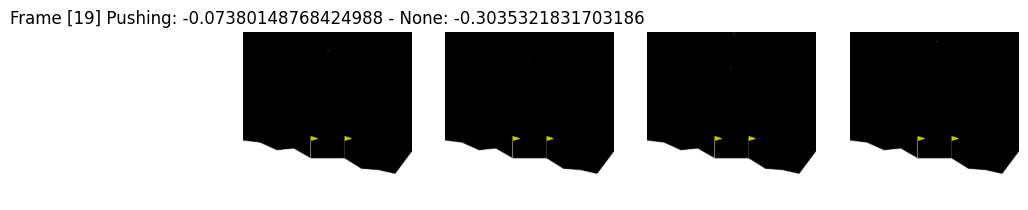

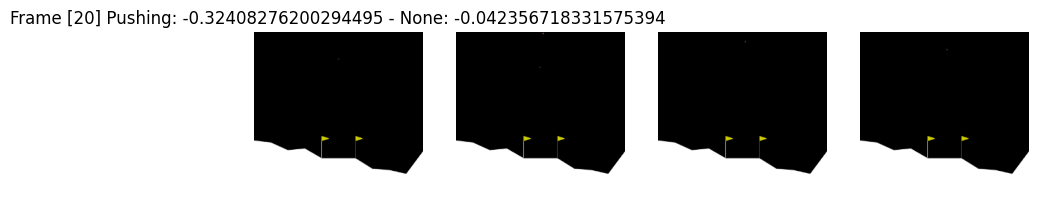

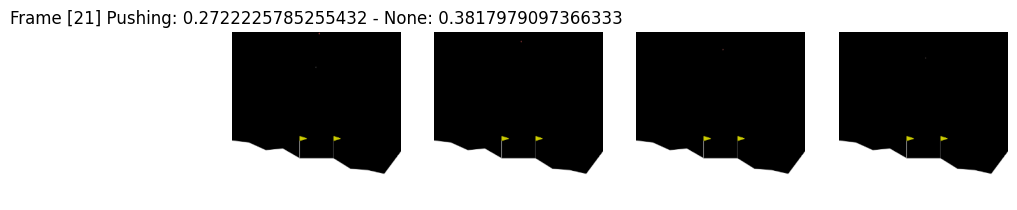

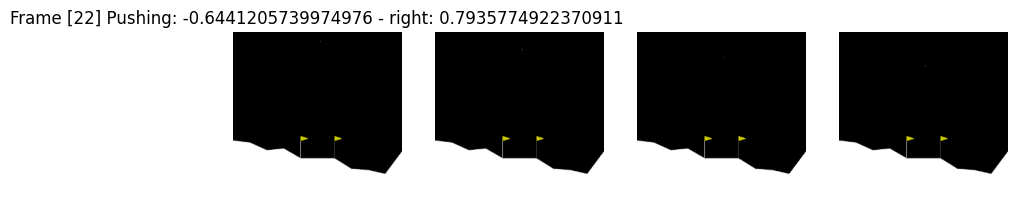

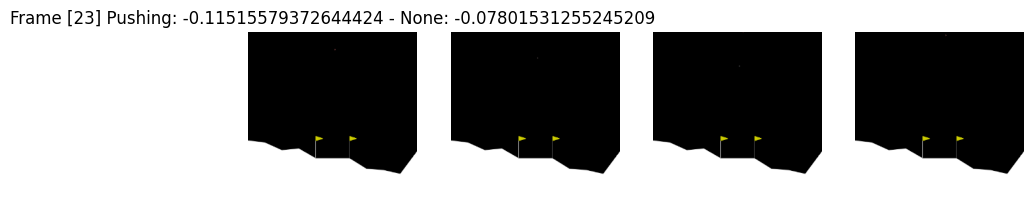

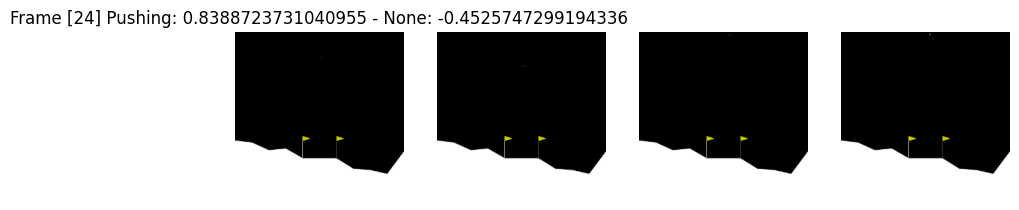

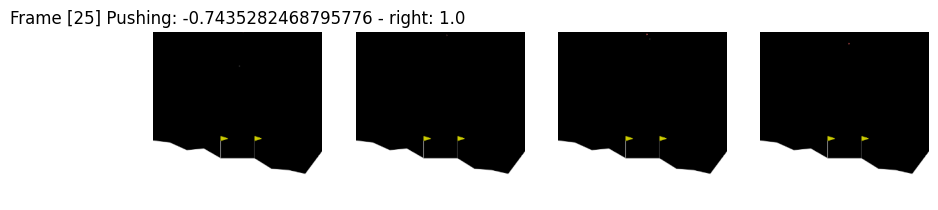

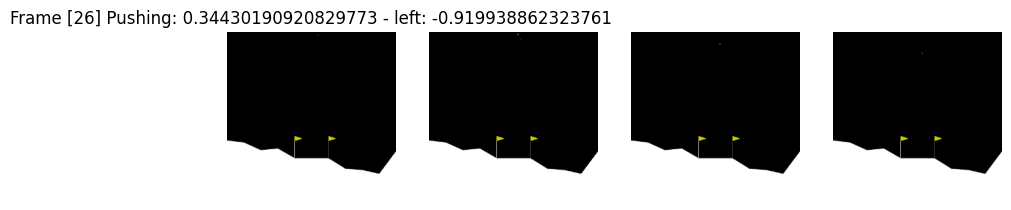

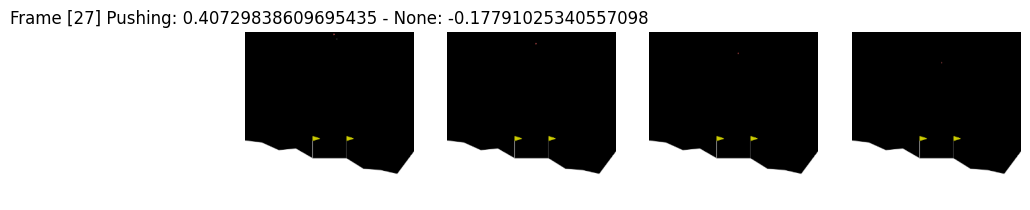

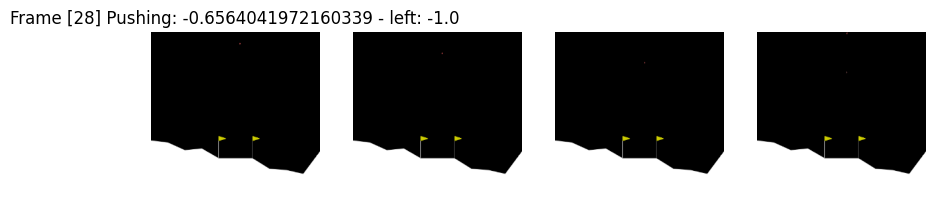

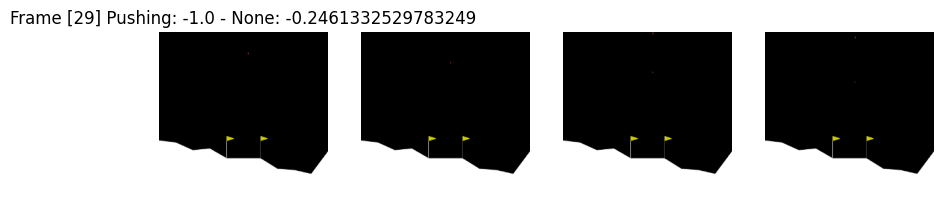

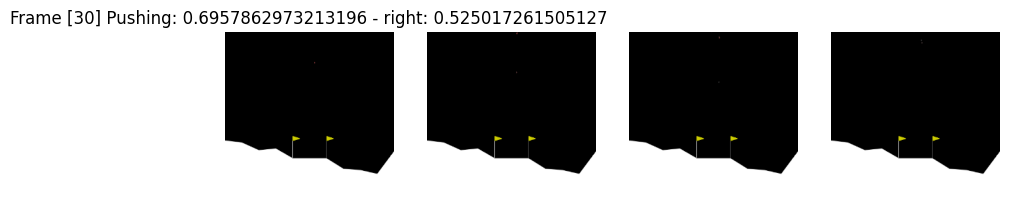

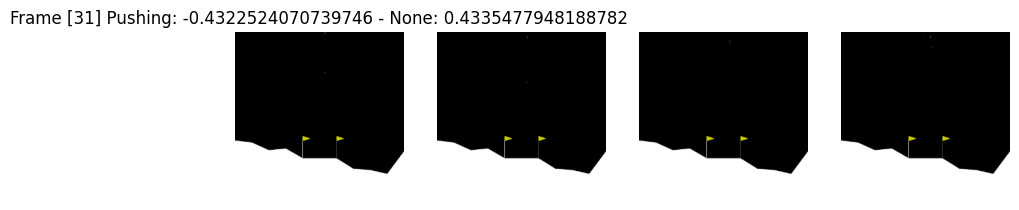

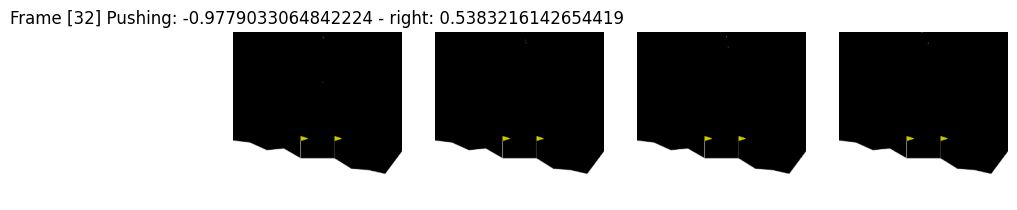

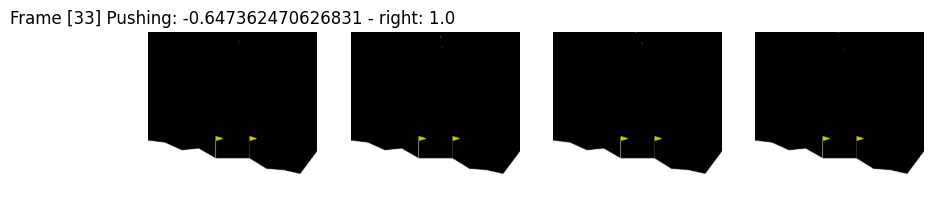

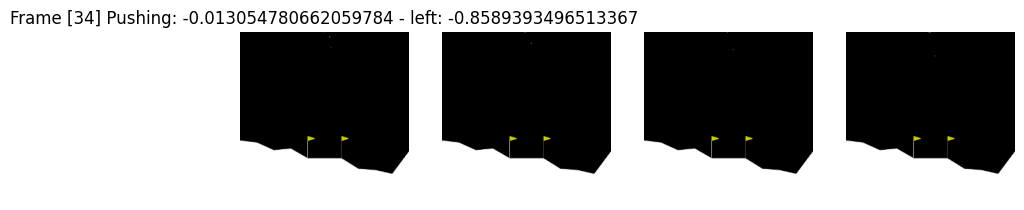

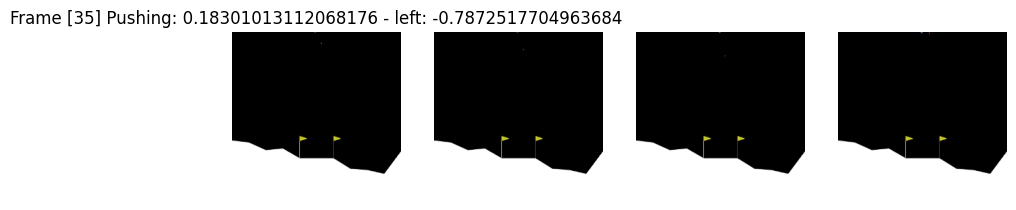

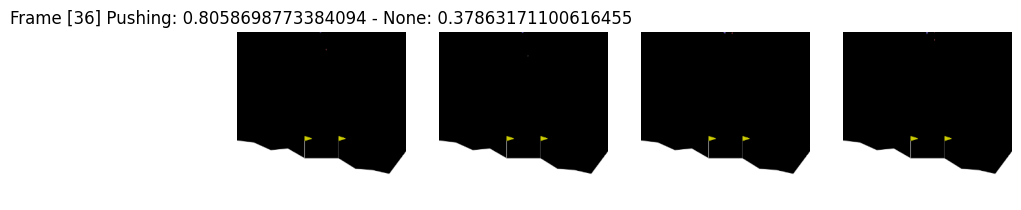

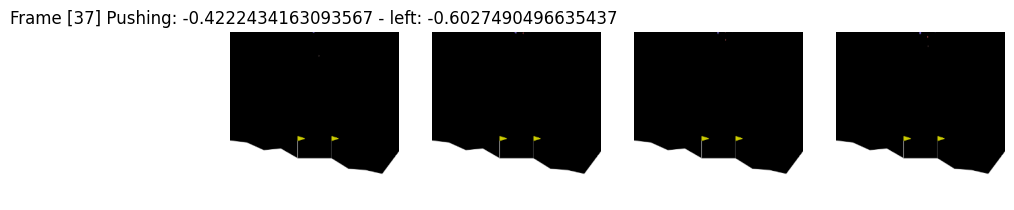

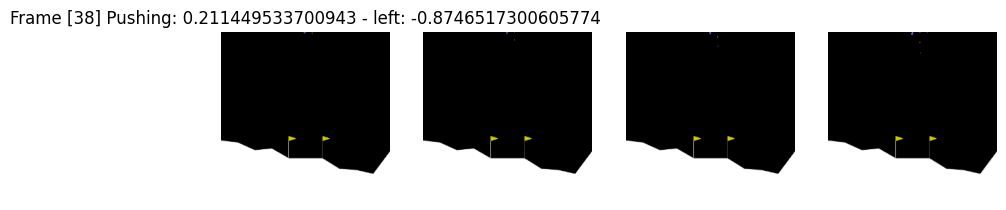

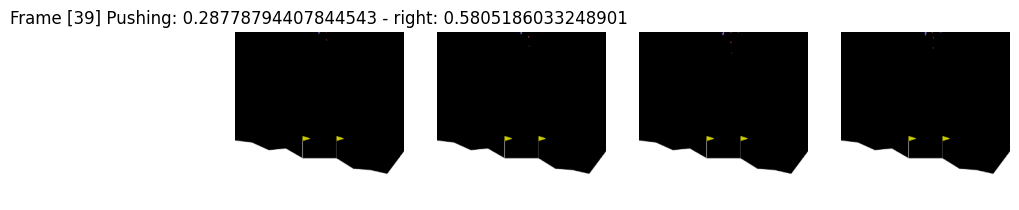

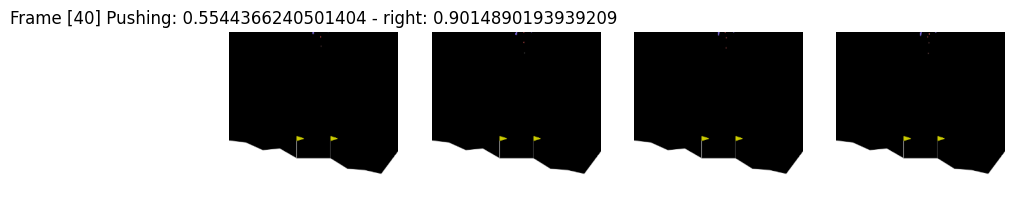

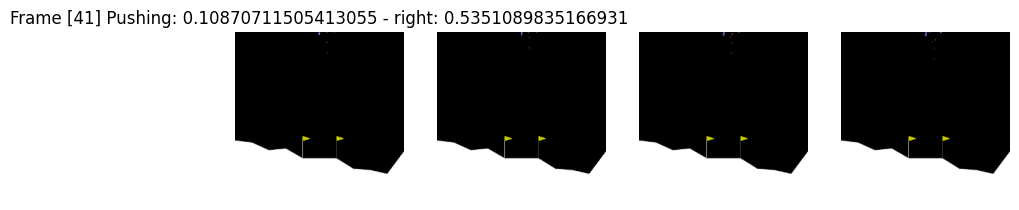

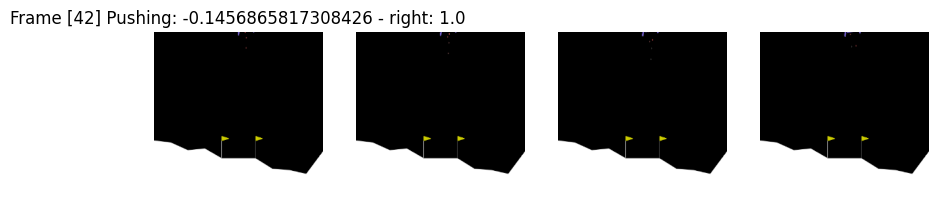

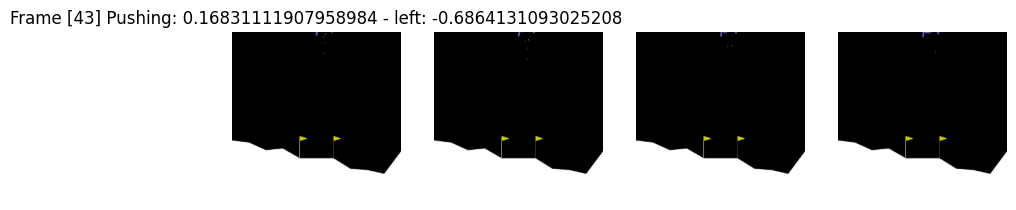

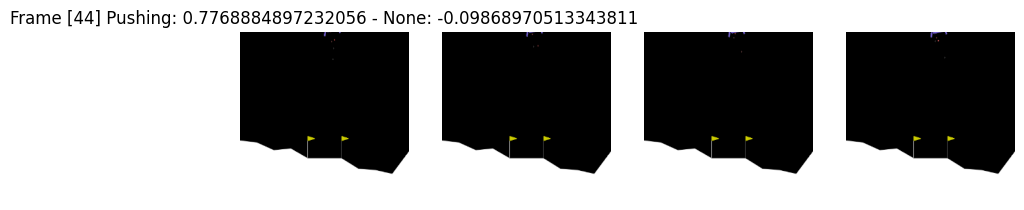

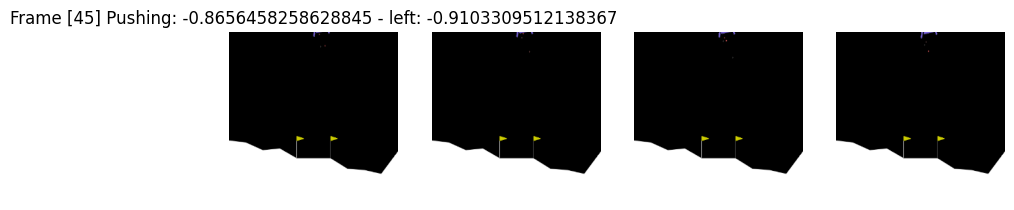

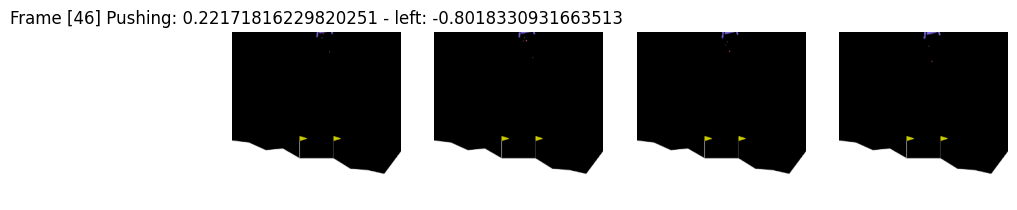

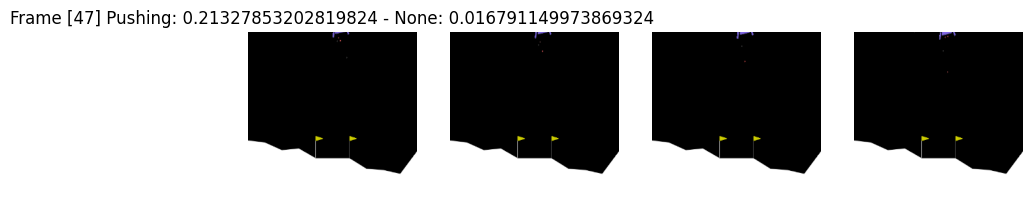

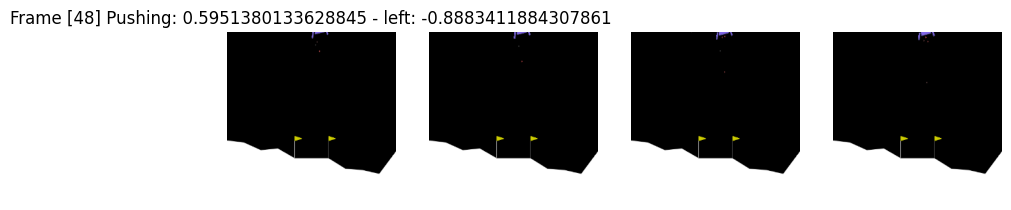

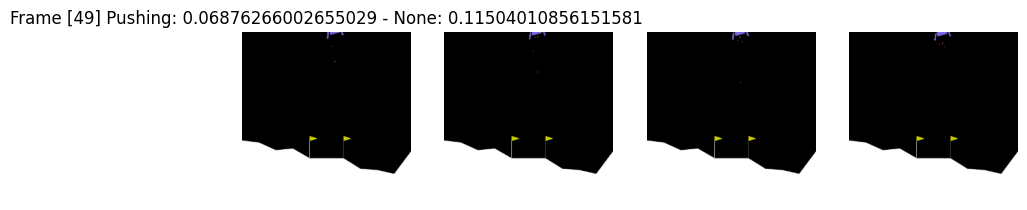

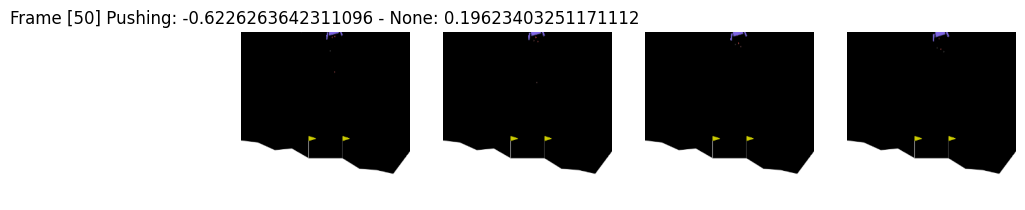

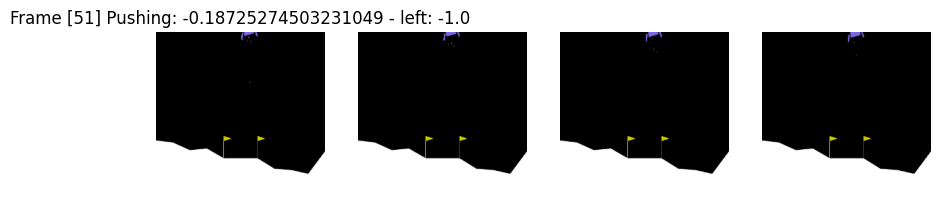

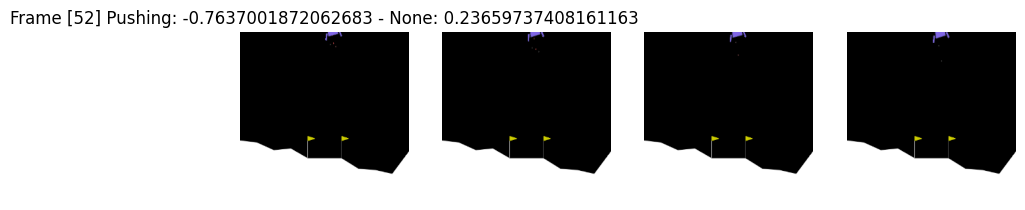

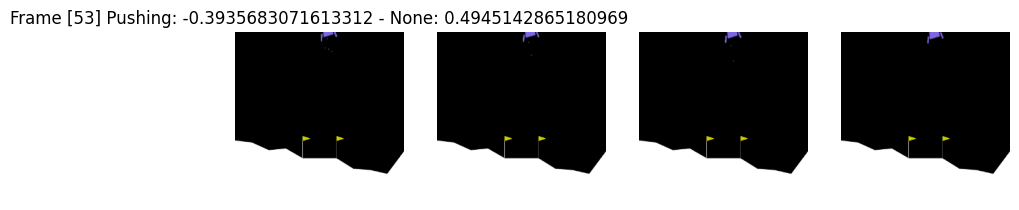

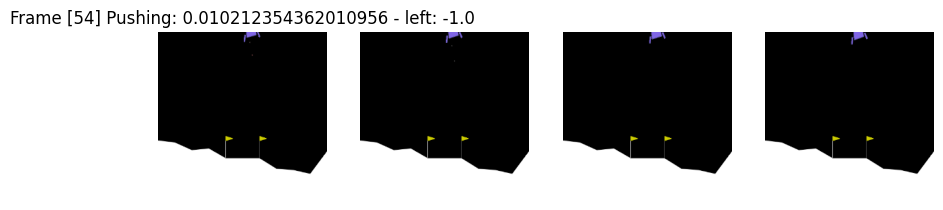

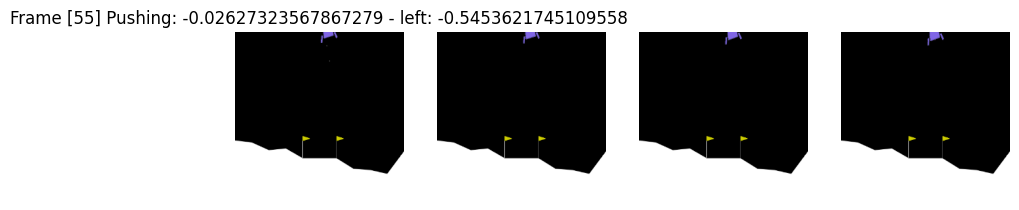

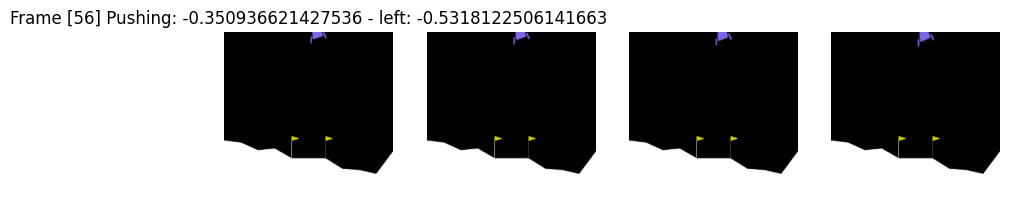

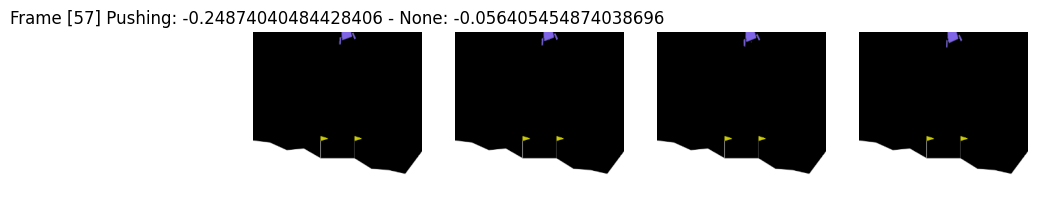

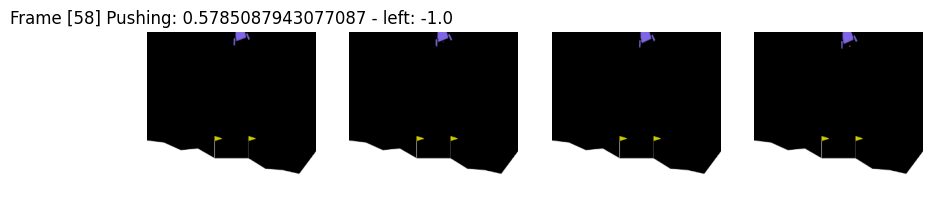

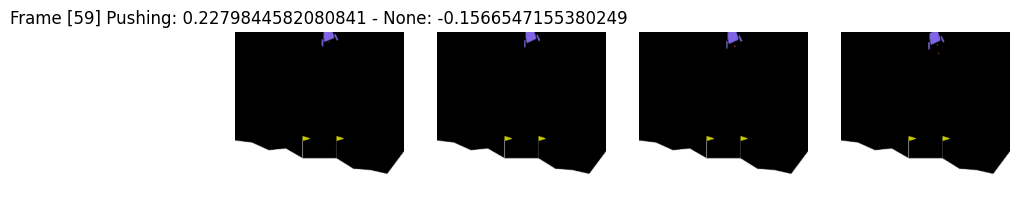

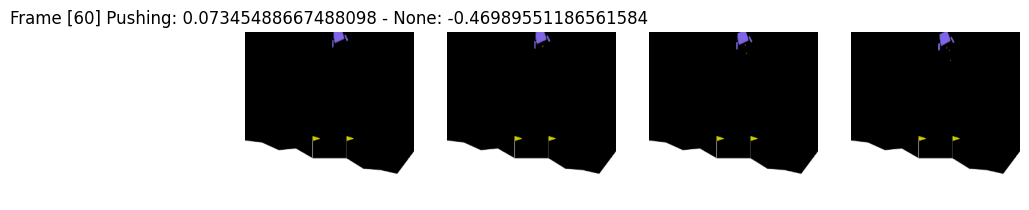

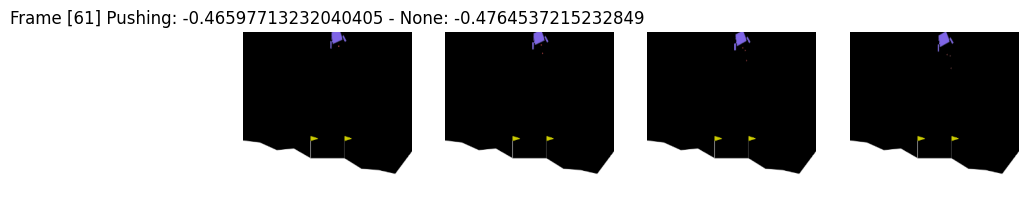

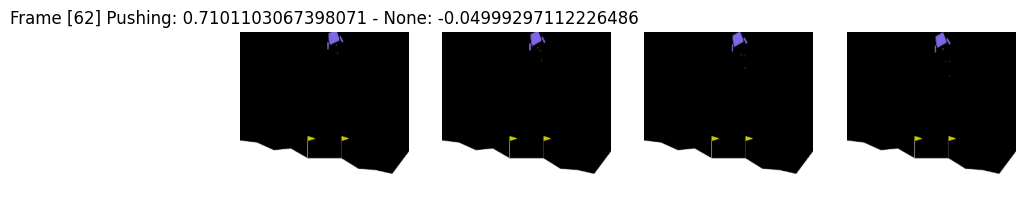

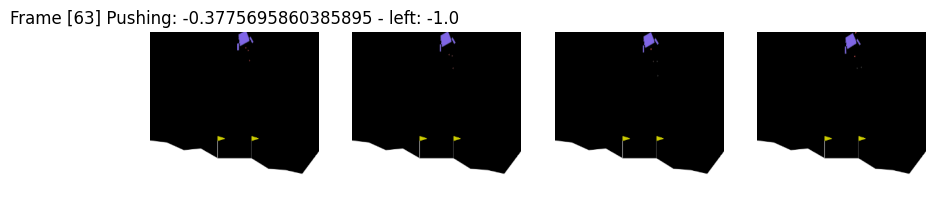

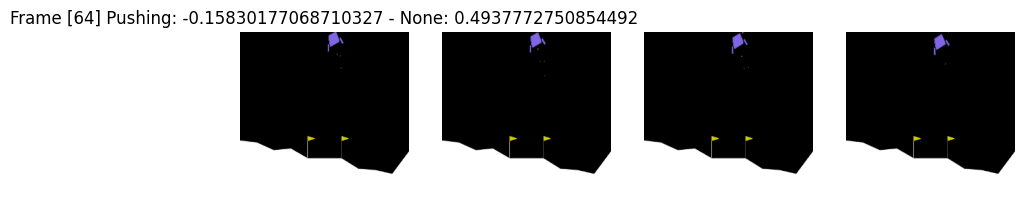

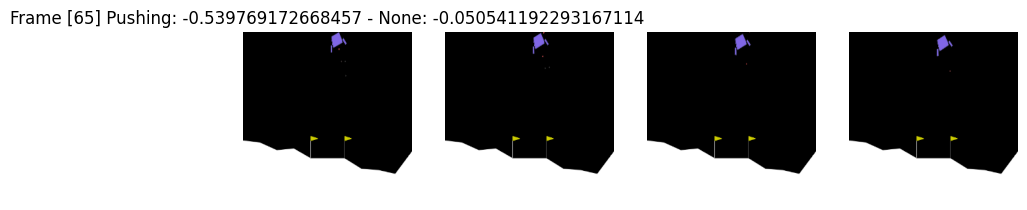

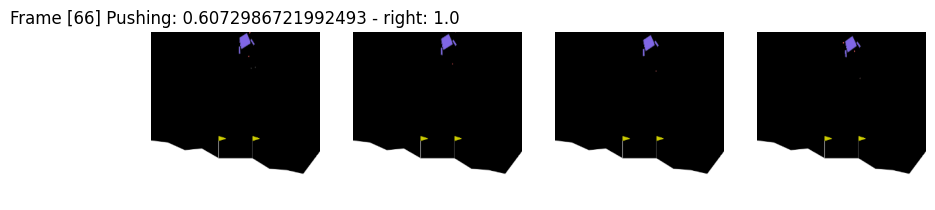

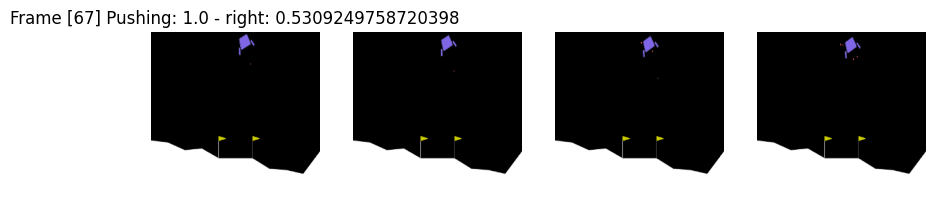

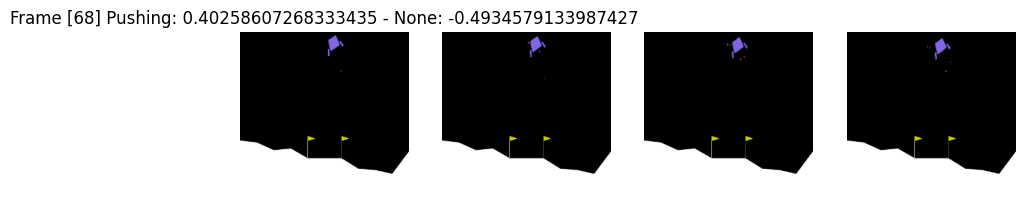

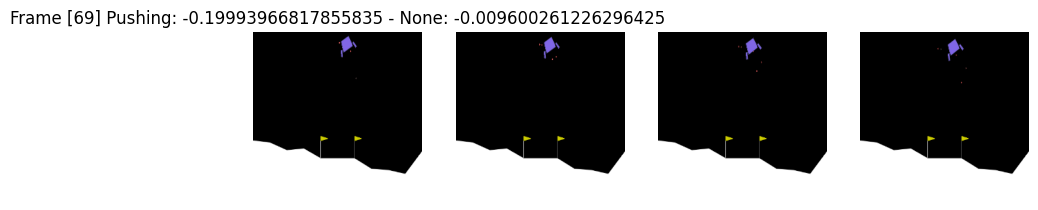

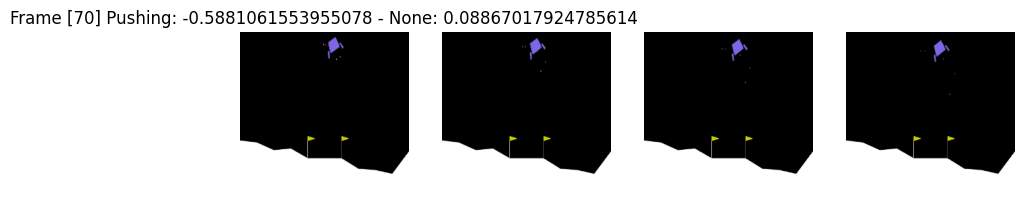

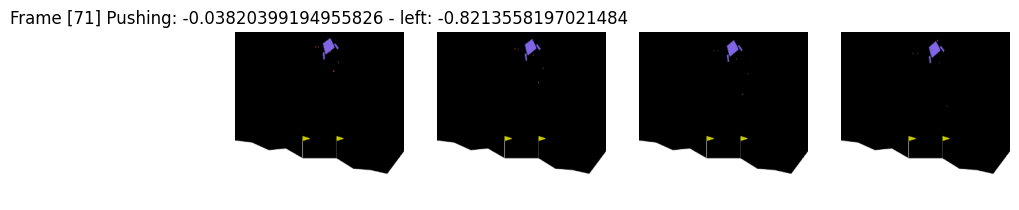

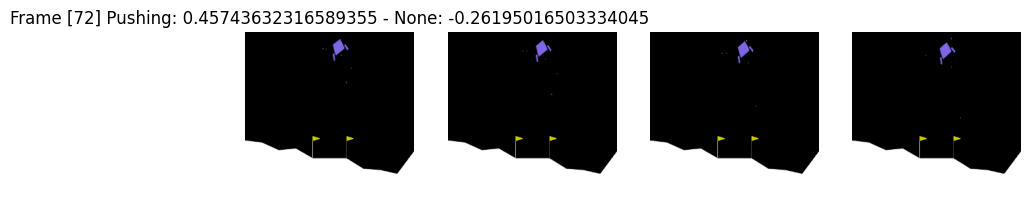

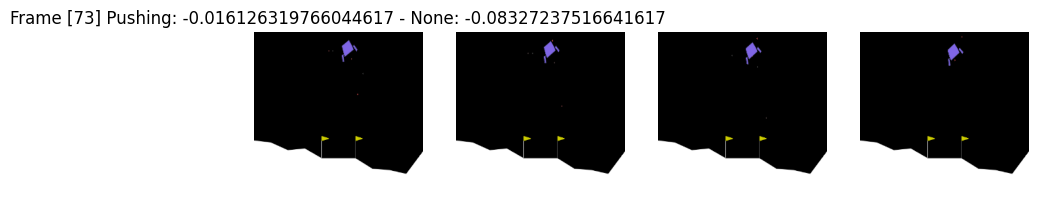

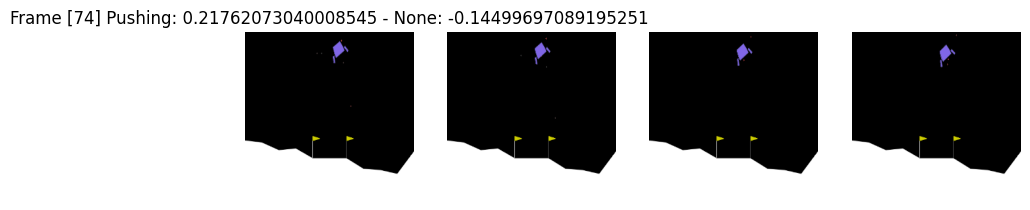

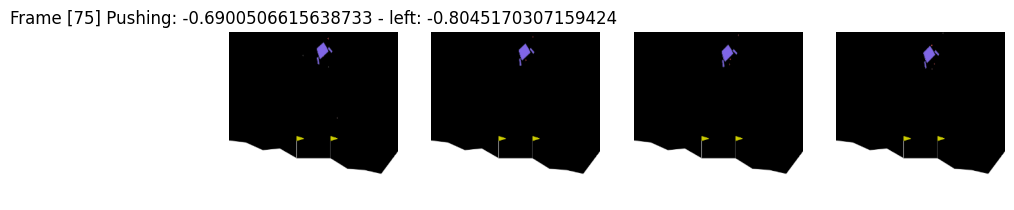

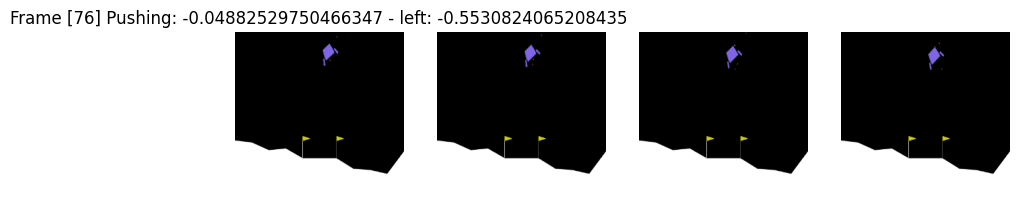

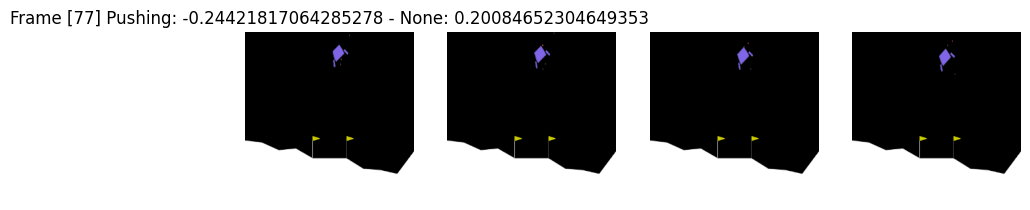

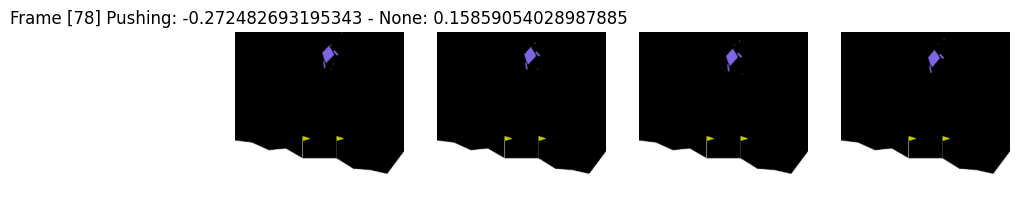

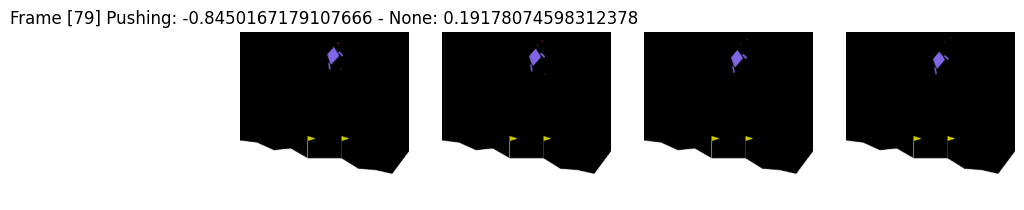

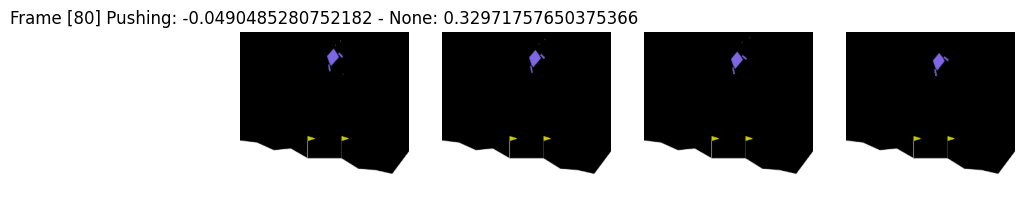

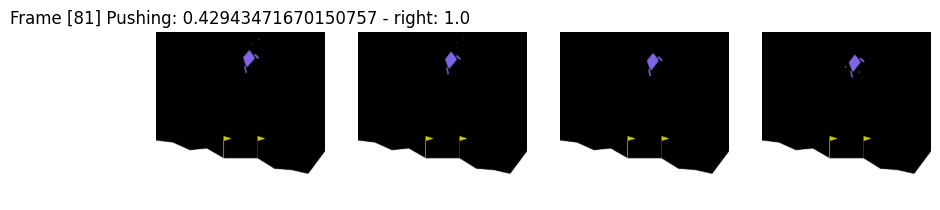

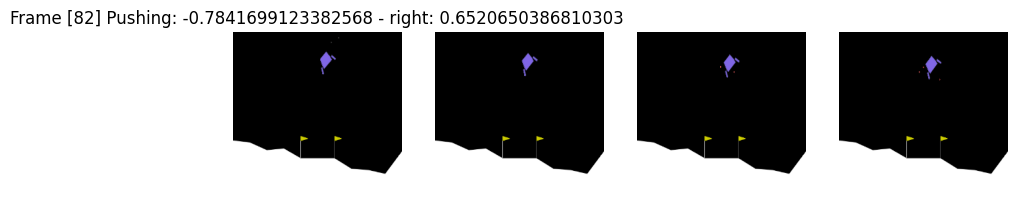

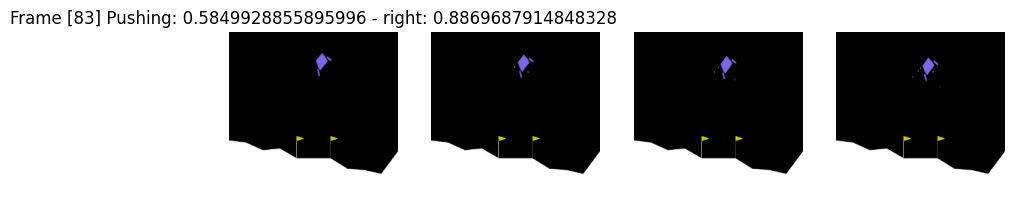

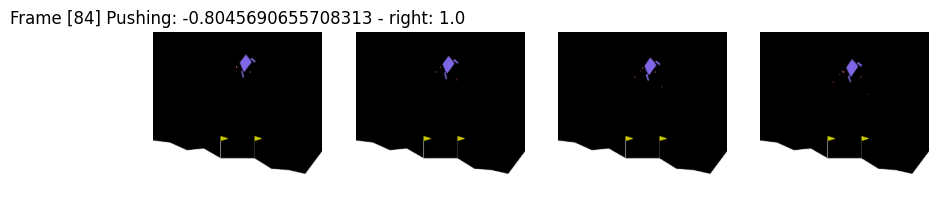

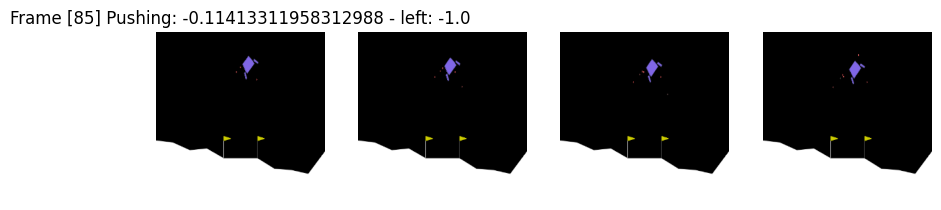

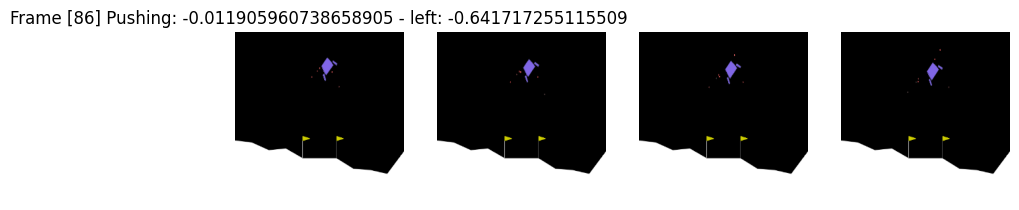

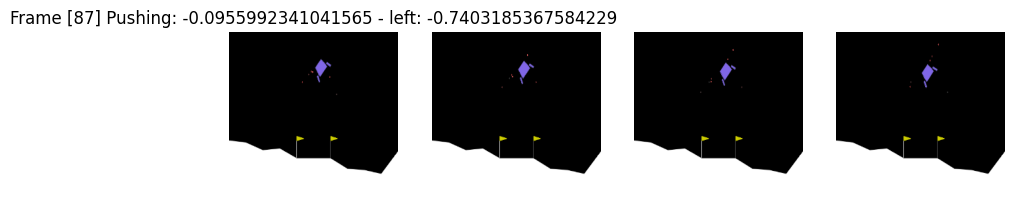

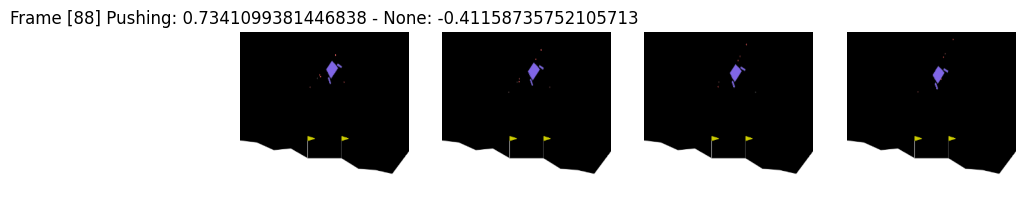

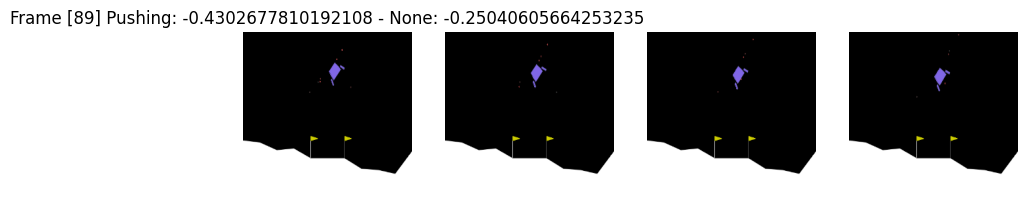

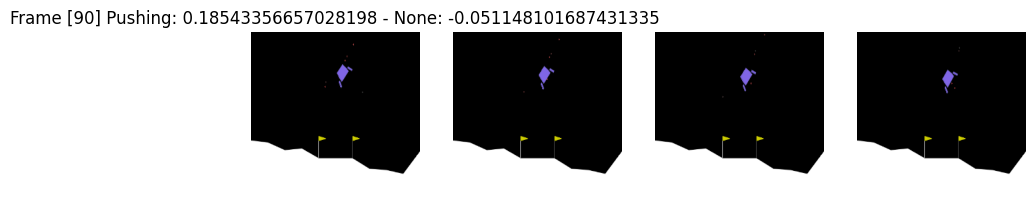

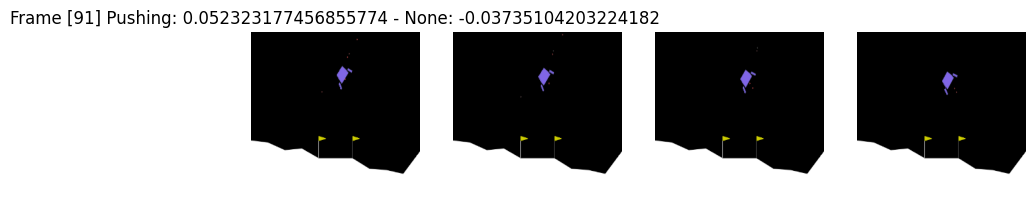

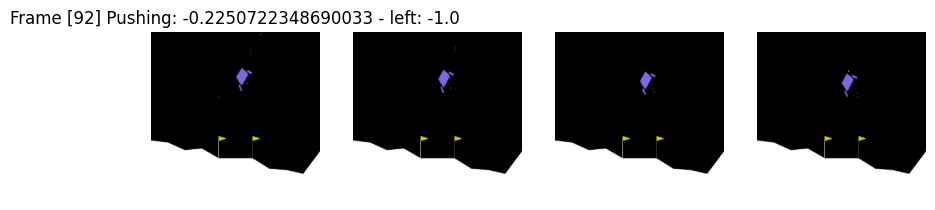

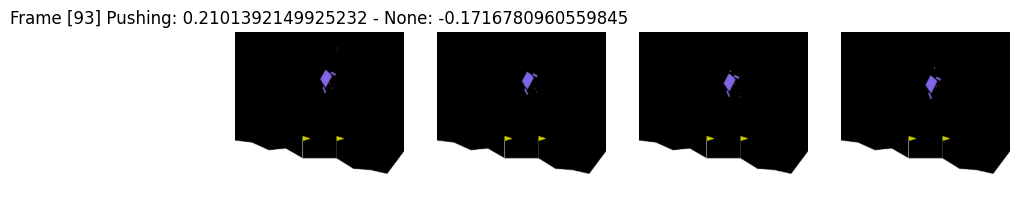

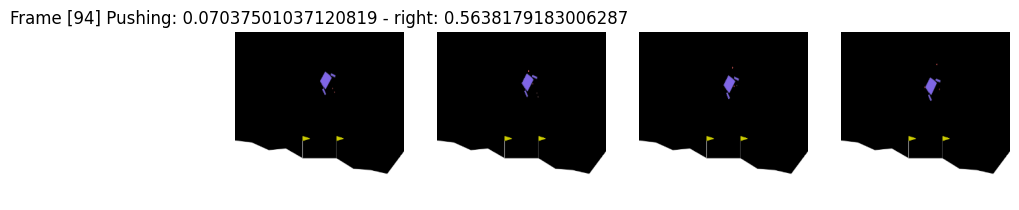

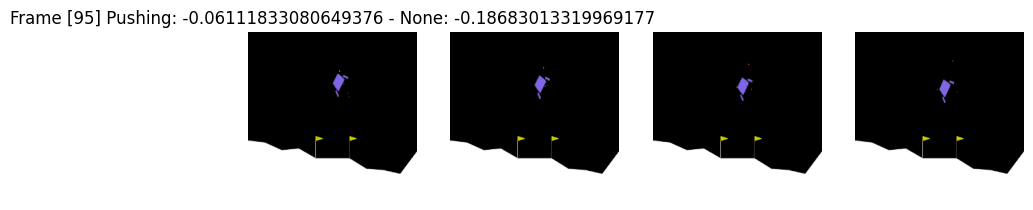

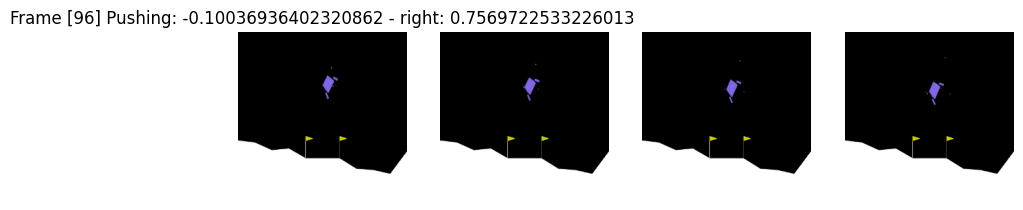

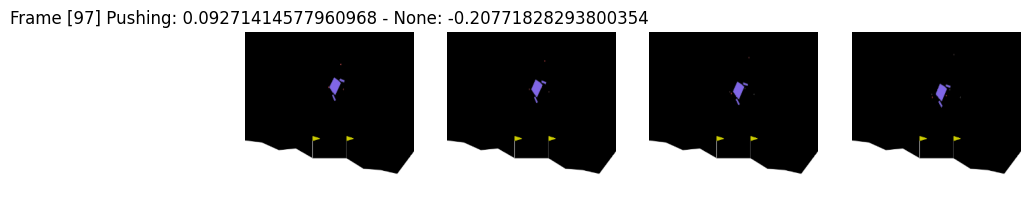

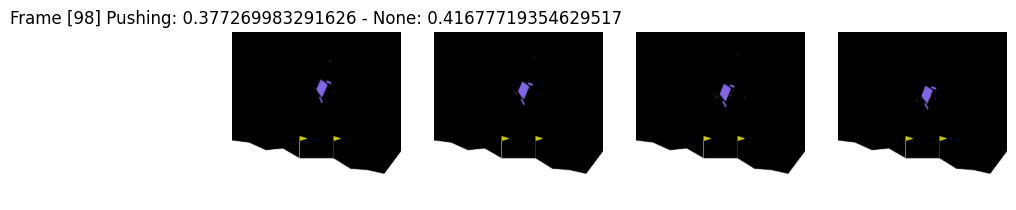

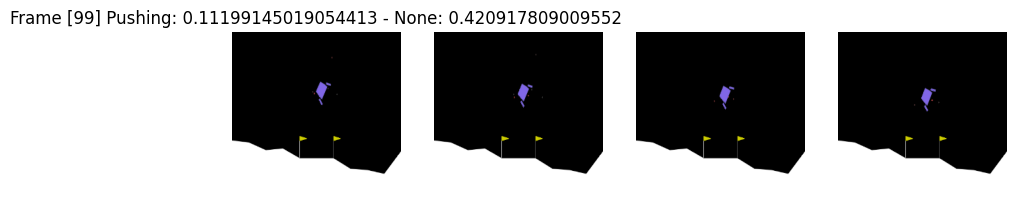

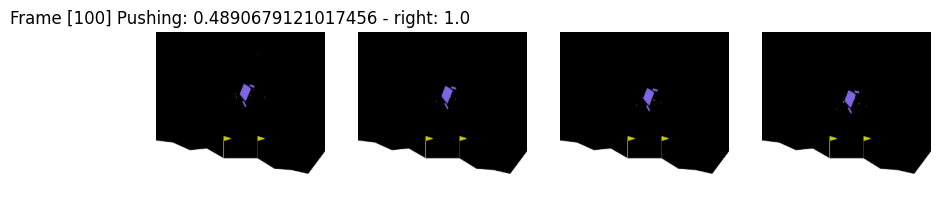

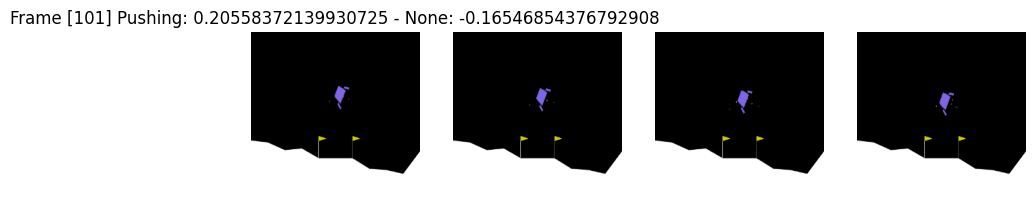

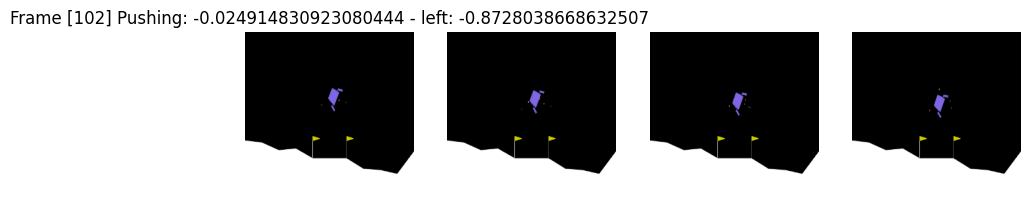

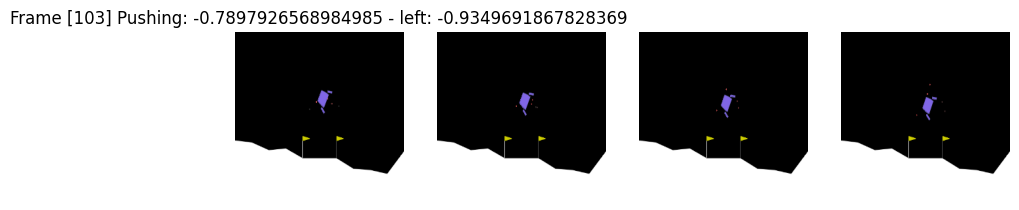

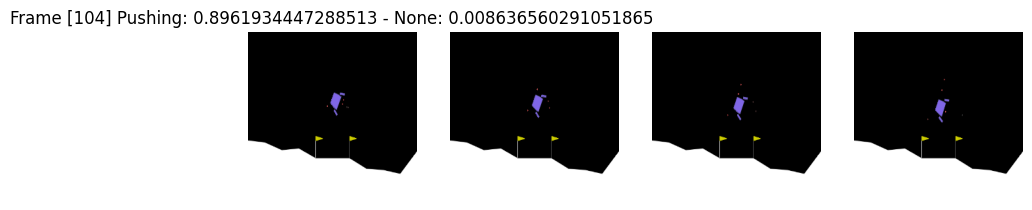

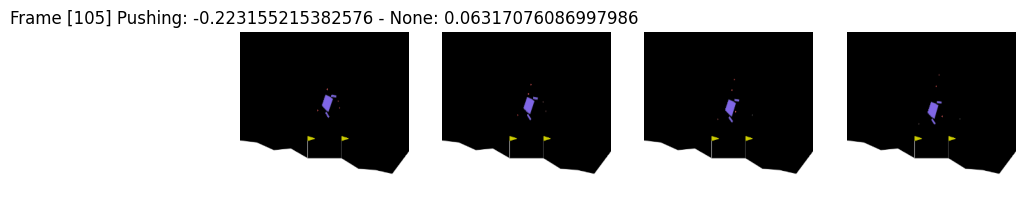

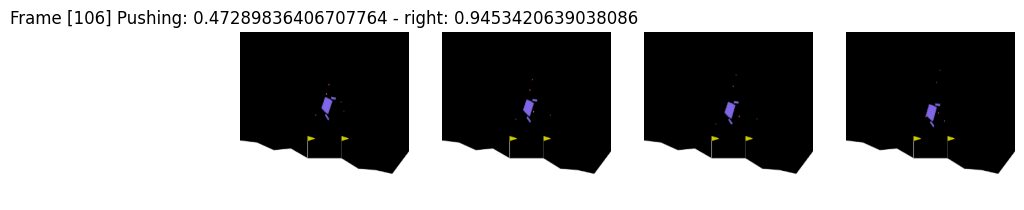

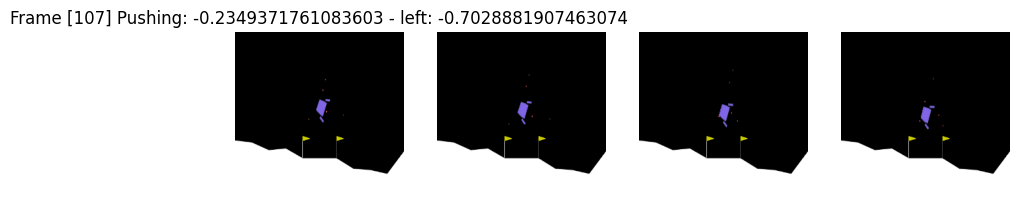

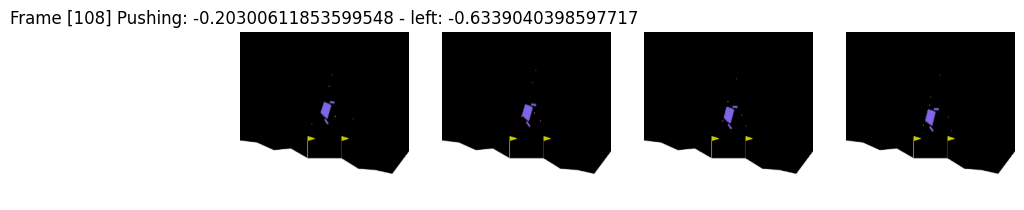

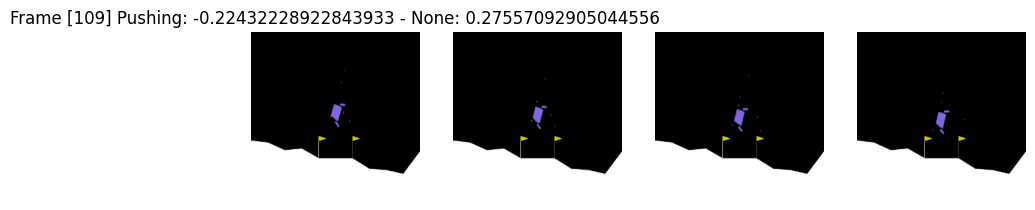

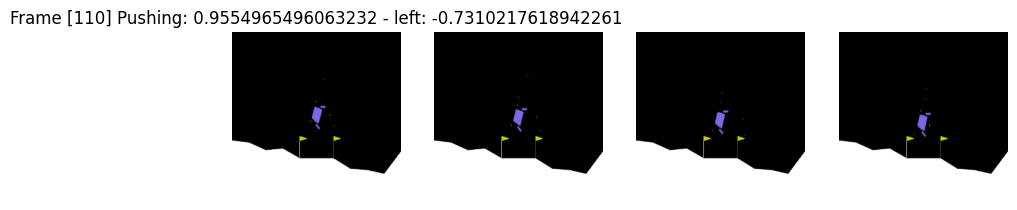

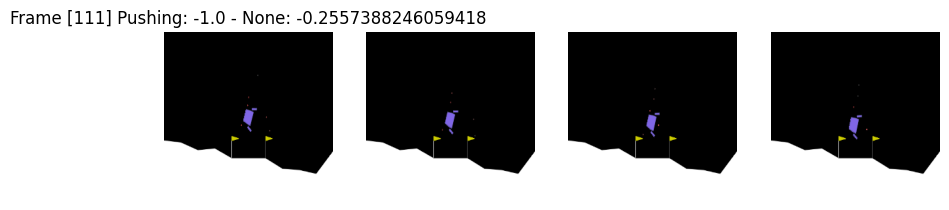

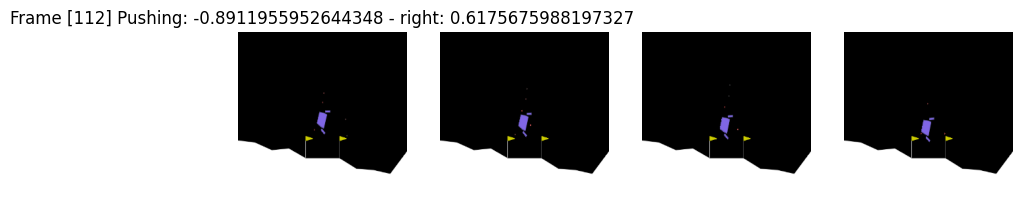

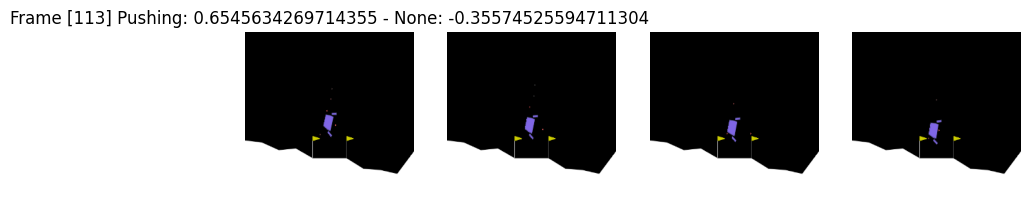

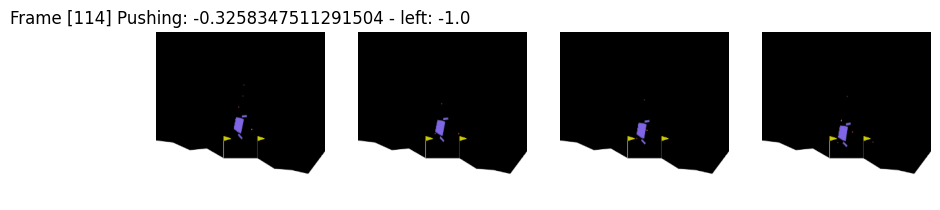

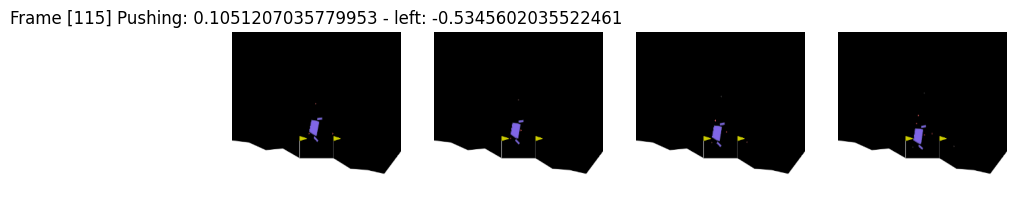

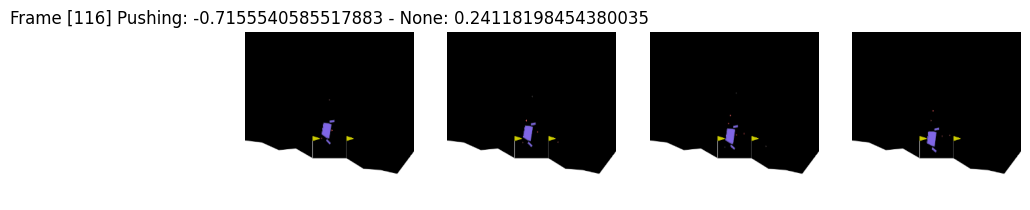

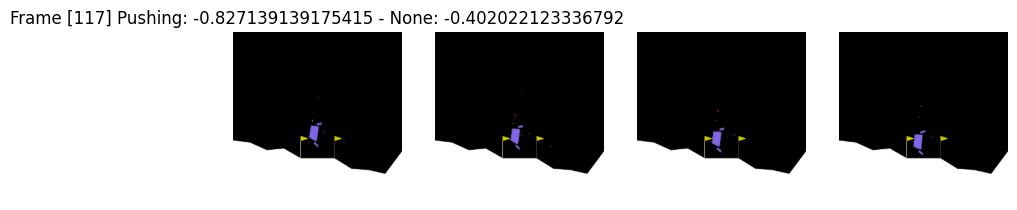

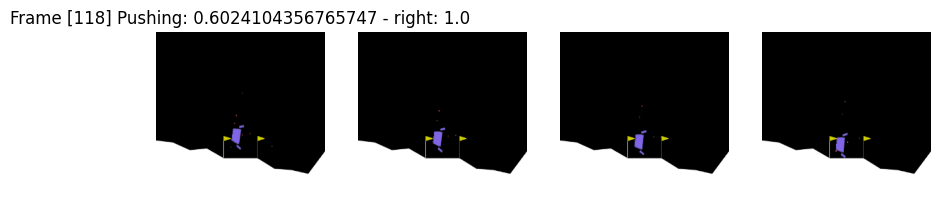

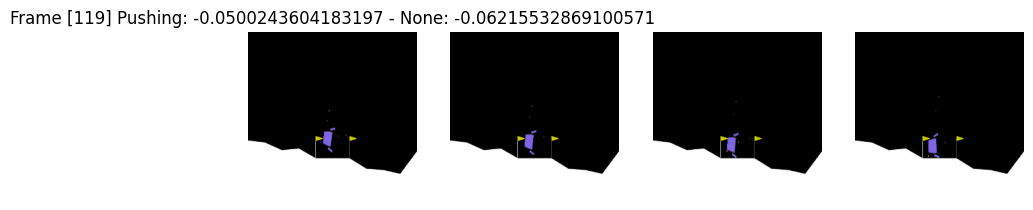

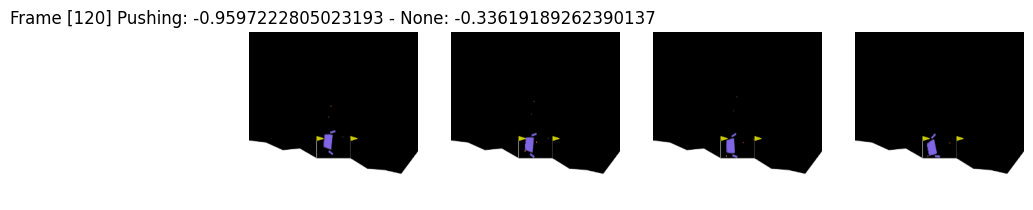

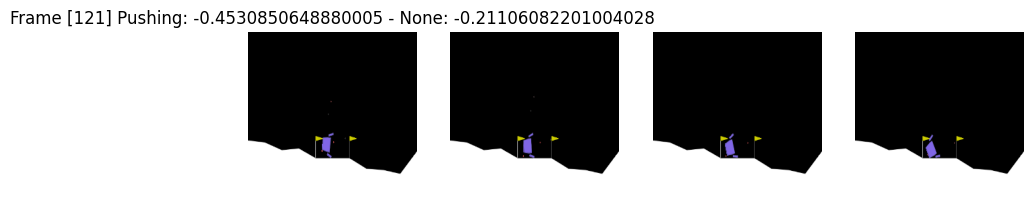

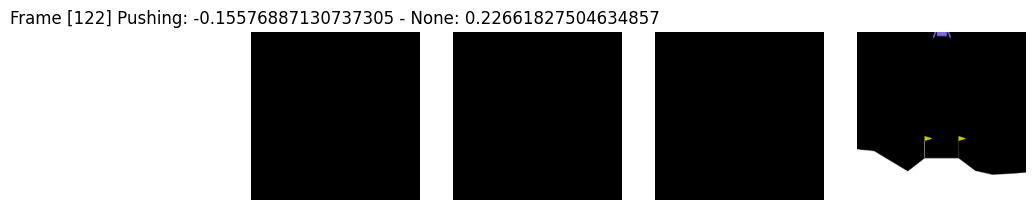

In [8]:
for i in range(len(df)):
    actions = np.squeeze(df.action[i])
    pushing = actions[0]
    side = "None"
    if actions[1] < -0.5:
        side = "left"
    elif actions[1] > 0.5:
        side = "right"
    
    plot_obs(df.state[i], 
             title=f"Frame [{i}] Pushing: {pushing} - {side}: {actions[1]}", 
             n_frame=4)

In [9]:
model_ckpt = "../../run/ppo_vislunarlander_default/artifacts/ppo_vislunarlander_229376_steps"
# model = PPO.load(model_ckpt)
model_ckpt_2 = "../../run/ppo_vislunarlander_default/artifacts/checkpoints/ppo_vislunarlander_90112_steps"
model = PPO.load(model_ckpt_2)

model

In [10]:
obs.shape

(1, 12, 256, 256)

In [11]:
import torch
from torchsummary import summary

summary(model.policy.features_extractor, obs[0].shape)

def extract_feature(obs):
    model.predict(df.state[50])

    obs_sample = torch.tensor(df.state[50], dtype=torch.float32).to("cpu")
    cnn_model = model.policy.features_extractor

    with torch.no_grad():
        layer_features = cnn_model.get_layer_features(obs_sample)

    return layer_features

layer_features = extract_feature(df.state[50])
layer_features.keys()

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 127, 127]             872
              ReLU-2          [-1, 8, 127, 127]               0
            Conv2d-3           [-1, 16, 63, 63]           1,168
              ReLU-4           [-1, 16, 63, 63]               0
         MaxPool2d-5           [-1, 16, 31, 31]               0
            Conv2d-6           [-1, 32, 15, 15]           4,640
              ReLU-7           [-1, 32, 15, 15]               0
         MaxPool2d-8             [-1, 32, 7, 7]               0
           Flatten-9                 [-1, 1568]               0
           Linear-10                  [-1, 256]         401,664
             ReLU-11                  [-1, 256]               0
Total params: 408,344
Trainable params: 408,344
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 3.00
Forward/

dict_keys(['layer1', 'layer2', 'layer3'])

In [17]:
print(df.state[50].shape)
print(layer_features["layer1"].numpy().shape)
print(layer_features["layer2"].numpy().shape)
print(layer_features["layer3"].numpy().shape)

(1, 12, 256, 256)
(1, 8, 127, 127)
(1, 16, 63, 63)
(1, 16, 31, 31)


In [13]:
torch.manual_seed(10)

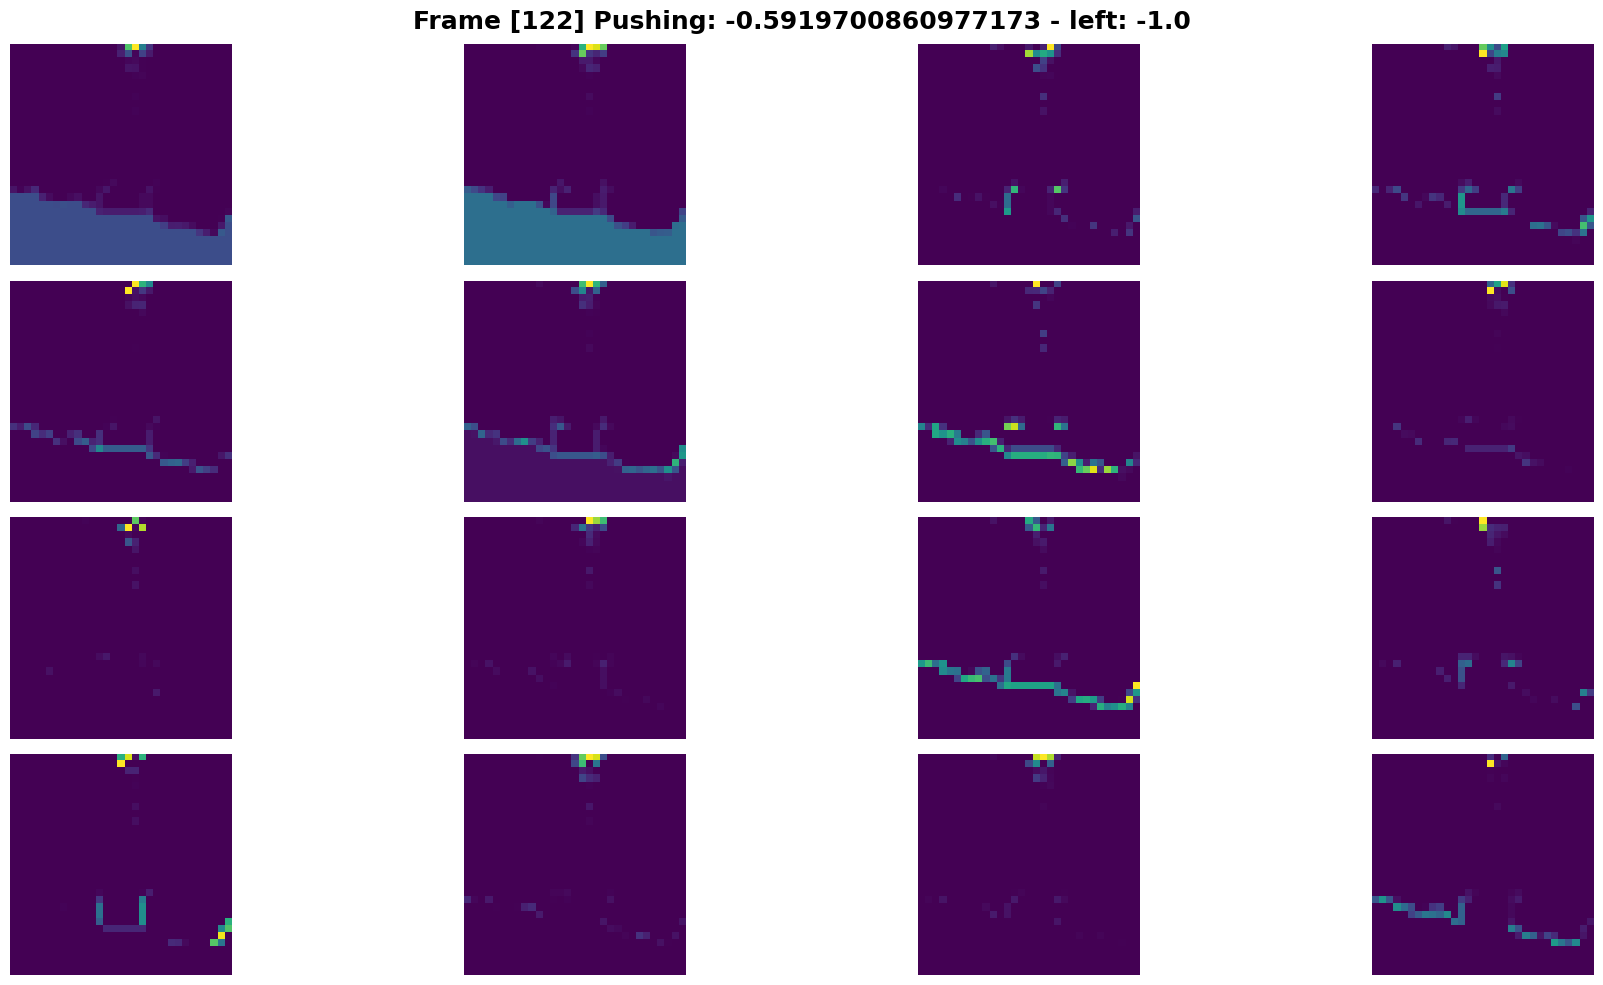

In [14]:
obs = df.state[62]
chosen_layer = "layer3"
layer_features = extract_feature(obs)
layer_features.keys()

nrow = layer_features[chosen_layer].numpy().shape[1]
ncol = np.ceil(nrow/4)
fig, ax = plt.subplots(4, ncol.astype(int), figsize=(20, 10))

for id in range(nrow):
    feature_map = layer_features[chosen_layer][0, id].detach().cpu().numpy()
    ax[int(id/ncol), int(id%ncol)].imshow(feature_map, cmap="viridis")
    ax[int(id/ncol), int(id%ncol)].axis("off")

actions, _ = model.predict(obs)
actions = np.squeeze(actions)
pushing = actions[0]
side = "None"
if actions[1] < -0.5:
    side = "left"
elif actions[1] > 0.5:
    side = "right"

fig.suptitle(f"Frame [{i}] Pushing: {pushing} - {side}: {actions[1]}", fontsize=18, fontweight='bold')
plt.tight_layout()


# Check model parameters

In [15]:
from src.model.cnn import CustomCNN_2

In [16]:
policy_kwargs = dict(
    features_extractor_class=CustomCNN_2,
    features_extractor_kwargs=dict(features_dim=256, num_frames=4)  # Adjust num_frames as needed
)

# Create the PPO agent using the custom feature extractor
checking_model = PPO(
    "CnnPolicy",
    env,
    policy_kwargs=policy_kwargs,
    verbose=1,
)

summary(checking_model.policy.features_extractor, obs[0].shape)

Using cpu device
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 127, 127]             872
              ReLU-2          [-1, 8, 127, 127]               0
            Conv2d-3           [-1, 16, 63, 63]           1,168
              ReLU-4           [-1, 16, 63, 63]               0
         MaxPool2d-5           [-1, 16, 31, 31]               0
            Conv2d-6           [-1, 32, 15, 15]           4,640
              ReLU-7           [-1, 32, 15, 15]               0
         MaxPool2d-8             [-1, 32, 7, 7]               0
           Flatten-9                 [-1, 1568]               0
           Linear-10                  [-1, 256]         401,664
             ReLU-11                  [-1, 256]               0
Total params: 408,344
Trainable params: 408,344
Non-trainable params: 0
----------------------------------------------------------------
Input size (M